In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
import matplotlib.gridspec as gridspec

Using: mps
Parameters: 12,737

   Epoch |       Loss |     L2 Err |    Max Err |      BC Viol
------------------------------------------------------------
     500 |   2.27e-03 |     0.0017 |   1.80e-03 |     0.00e+00
    1000 |   1.23e-02 |     0.0017 |   1.90e-03 |     0.00e+00
    1500 |   4.63e-03 |     0.0031 |   3.50e-03 |     0.00e+00
    2000 |   1.87e-03 |     0.0018 |   1.82e-03 |     0.00e+00
    2500 |   6.93e-05 |     0.0001 |   8.02e-05 |     0.00e+00
    3000 |   6.49e-04 |     0.0010 |   1.14e-03 |     0.00e+00
    3500 |   1.52e-04 |     0.0005 |   6.41e-04 |     0.00e+00
    4000 |   3.80e-05 |     0.0001 |   1.34e-04 |     0.00e+00
    4500 |   3.00e-05 |     0.0000 |   5.13e-05 |     0.00e+00
    5000 |   4.55e-05 |     0.0002 |   2.12e-04 |     0.00e+00
    5500 |   2.15e-05 |     0.0000 |   1.97e-05 |     0.00e+00
    6000 |   1.86e-05 |     0.0000 |   4.67e-05 |     0.00e+00
    6500 |   1.57e-05 |     0.0000 |   3.71e-05 |     0.00e+00
    7000 |   1.36e-05 |   

/var/folders/xy/b5kwft7572392kjr5nf85tkh0000gn/T/ipykernel_2510/2543279797.py:239: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax6.axhline(y=1e-6, color='gray', ls='--', label='Machine precision ~1e-7')


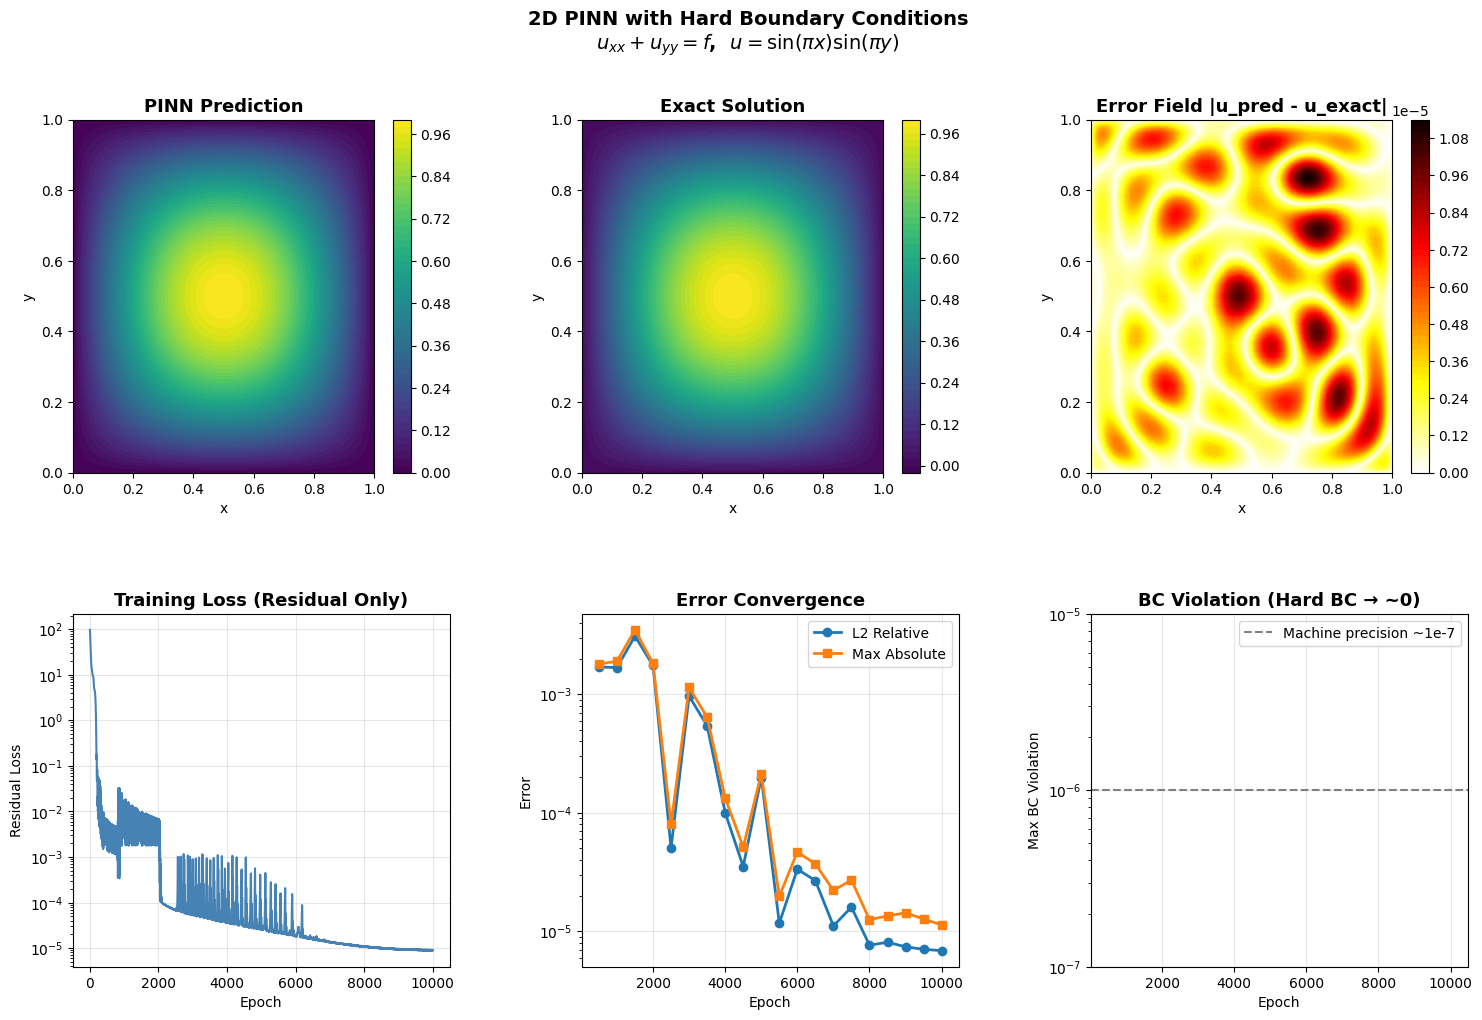


Final L2 Relative Error : 0.000007
Final Max Absolute Error: 1.132488e-05
Final BC Violation      : 0.000000e+00  ← should be ~1e-7


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Set seeds for reproducibility 
torch.manual_seed(42)
np.random.seed(42)

# Check for CUDA, then MPS, then fallback to CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(42) # Added seed for Mac GPU
else:
    device = torch.device("cpu")

print(f"Using: {device}")

class PINN(nn.Module):
    # DEFINE MODEL
    def __init__(self, layers=[2, 64, 64, 64, 64, 1]):
        super(PINN, self).__init__()
        network = []
        for i in range(len(layers)-1):
            network.append(nn.Linear(layers[i], layers[i+1]))
            if (i < len(layers)-2):
                network.append(nn.Tanh())
        self.net = nn.Sequential(*network)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    # DIRICHLET FUNCTION FOR HARD BOUNDARY
    def distance_fn(self, x, y):
        return x * (1 - x) * y * (1 - y)
    
    # MODIFIED FORWARD PASS
    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        N_out = self.net(inp)
        phi = self.distance_fn(x, y)
        return N_out * phi

# ==========================================
# HELPER FUNCTIONS (Moved outside the class)
# ==========================================

# RESIDUAL U_XX + U_YY - F(X,Y)
def compute_residual(model, x, y):
    u = model(x, y)
    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]
    u_y = torch.autograd.grad(
        u, y,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]
    u_yy = torch.autograd.grad(
        u_y, y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True,
        retain_graph=True
    )[0]
    
    pi = torch.tensor(torch.pi, device=x.device)
    f = -2.0 * pi**2 * torch.sin(pi * x) * torch.sin(pi * y)

    return u_xx + u_yy - f

# INTERIOR SAMPLE (using sobol)
def sample_interior(N):
    sobol = torch.quasirandom.SobolEngine(dimension=2, scramble=True)
    samples = sobol.draw(N).to(device)

    # Fixed slicing and requires_grad_()
    x = samples[:, 0:1].clone().detach().requires_grad_(True)
    y = samples[:, 1:2].clone().detach().requires_grad_(True)

    return x, y

# LOSS FUNCTION
def pinn_loss(model, x, y):
    res = compute_residual(model, x, y)
    # Fixed: Use torch.mean, not np.mean for tensors with gradients
    return torch.mean(res**2)

# EXACT SOLUTION
def u_exact(x, y):
    pi = torch.tensor(torch.pi, device=x.device)
    return torch.sin(pi * x) * torch.sin(pi * y)

# METRICS
def compute_metrics(model, N=300):
    xlin = torch.linspace(0, 1, N, device=device)
    ylin = torch.linspace(0, 1, N, device=device)

    X, Y = torch.meshgrid(xlin, ylin, indexing='ij')

    xf = X.reshape(-1, 1)
    yf = Y.reshape(-1, 1)

    with torch.no_grad():
        u_pred = model(xf, yf)
        u_true = u_exact(xf, yf)
    
    l2  = (torch.norm(u_pred - u_true) / torch.norm(u_true)).item()
    max_err = torch.max(torch.abs(u_pred - u_true)).item()

    t = torch.linspace(0, 1, 1000, device=device).reshape(-1, 1)
    z = torch.zeros_like(t)
    o = torch.ones_like(t)

    with torch.no_grad():
        bc_violations = [
            torch.max(torch.abs(model(t, z))).item(),   # bottom y=0
            torch.max(torch.abs(model(t, o))).item(),   # top    y=1
            torch.max(torch.abs(model(z, t))).item(),   # left   x=0
            torch.max(torch.abs(model(o, t))).item(),   # right  x=1
        ]

    return l2, max_err, max(bc_violations)

def train(model, n_epochs=100, N_interior=0, lr=1e-3, log_every=500):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-5
    )

    history = {
    'loss': [], 'l2_error': [], 'max_error': [], 'bc_violation': []
    }

    print(f"{'Epoch':>8} | {'Loss':>10} | {'L2 Err':>10} | "
      f"{'Max Err':>10} | {'BC Viol':>12}")
    print("-" * 60)

    for epoch in range(1, n_epochs+1):
        model.train()
        optimizer.zero_grad()

        x, y = sample_interior(N_interior)

        loss = pinn_loss(model, x, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        history['loss'].append(loss.item())

        if (epoch % log_every == 0):
            model.eval()
            l2, max_err, bc_viol = compute_metrics(model)
            history['l2_error'].append(l2)
            history['max_error'].append(max_err)
            history['bc_violation'].append(bc_viol)

            print(f"{epoch:>8} | {loss.item():>10.2e} | {l2:>10.4f} | "
                f"{max_err:>10.2e} | {bc_viol:>12.2e}")

    return history

def plot_results(model, history):
    N = 300
    x_lin = torch.linspace(0, 1, N, device=device)
    y_lin = torch.linspace(0, 1, N, device=device)
    X, Y  = torch.meshgrid(x_lin, y_lin, indexing='ij')
    xf    = X.reshape(-1, 1)
    yf    = Y.reshape(-1, 1)

    with torch.no_grad():
        U_pred = model(xf, yf).reshape(X.shape).cpu().numpy()

    U_exact_np = u_exact(xf, yf).reshape(X.shape).cpu().numpy()
    Error      = np.abs(U_pred - U_exact_np)
    Xnp, Ynp   = X.cpu().numpy(), Y.cpu().numpy()

    fig = plt.figure(figsize=(18, 11))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # Panel 1: Prediction
    ax1 = fig.add_subplot(gs[0, 0])
    c1  = ax1.contourf(Xnp, Ynp, U_pred, levels=60, cmap='viridis')
    plt.colorbar(c1, ax=ax1)
    ax1.set_title('PINN Prediction', fontsize=13, fontweight='bold')
    ax1.set_xlabel('x'); ax1.set_ylabel('y')

    # Panel 2: Exact
    ax2 = fig.add_subplot(gs[0, 1])
    c2  = ax2.contourf(Xnp, Ynp, U_exact_np, levels=60, cmap='viridis')
    plt.colorbar(c2, ax=ax2)
    ax2.set_title('Exact Solution', fontsize=13, fontweight='bold')
    ax2.set_xlabel('x'); ax2.set_ylabel('y')

    # Panel 3: Error field
    ax3 = fig.add_subplot(gs[0, 2])
    c3  = ax3.contourf(Xnp, Ynp, Error, levels=60, cmap='hot_r')
    plt.colorbar(c3, ax=ax3)
    ax3.set_title('Error Field |u_pred - u_exact|', fontsize=13, fontweight='bold')
    ax3.set_xlabel('x'); ax3.set_ylabel('y')

    # Panel 4: Loss curve
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.semilogy(history['loss'], color='steelblue', lw=1.5)
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Residual Loss')
    ax4.set_title('Training Loss (Residual Only)', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3)

    # Panel 5: L2 + Max error
    ax5 = fig.add_subplot(gs[1, 1])
    eval_ep = [i * 500 for i in range(1, len(history['l2_error']) + 1)]
    ax5.semilogy(eval_ep, history['l2_error'],  'o-', label='L2 Relative', lw=2)
    ax5.semilogy(eval_ep, history['max_error'], 's-', label='Max Absolute', lw=2)
    ax5.set_xlabel('Epoch'); ax5.set_ylabel('Error')
    ax5.set_title('Error Convergence', fontsize=13, fontweight='bold')
    ax5.legend(); ax5.grid(True, alpha=0.3)

    # Panel 6: BC violation — KEY PLOT
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.semilogy(eval_ep, history['bc_violation'], 'D-', color='red', lw=2)
    ax6.axhline(y=1e-6, color='gray', ls='--', label='Machine precision ~1e-7')
    ax6.set_xlabel('Epoch'); ax6.set_ylabel('Max BC Violation')
    ax6.set_title('BC Violation (Hard BC → ~0)', fontsize=13, fontweight='bold')
    ax6.legend(); ax6.grid(True, alpha=0.3)

    plt.suptitle('2D PINN with Hard Boundary Conditions\n'
                r'$u_{xx} + u_{yy} = f$,  $u=\sin(\pi x)\sin(\pi y)$',
                fontsize=14, fontweight='bold')

    plt.savefig('hard_bc_pinn.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Final metrics
    l2, max_err, bc_viol = compute_metrics(model, N=500)
    print(f"\n{'='*50}")
    print(f"Final L2 Relative Error : {l2:.6f}")
    print(f"Final Max Absolute Error: {max_err:.6e}")
    print(f"Final BC Violation      : {bc_viol:.6e}  ← should be ~1e-7")
    print(f"{'='*50}")

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    model   = PINN(layers=[2, 64, 64, 64, 64, 1]).to(device)
    params  = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {params:,}\n")

    history = train(model, n_epochs=10000,
                    N_interior=3000, lr=1e-3, log_every=500)

    plot_results(model, history)